# CAIM Lab Session 3: Programming with Elastic Search

In this session you will:

- Learn how to tell ElasticSearch to apply different tokenizers and filters to the documents, like removing stopwords or stemming the words.
- Study how these changes affect the terms that ElasticSearch puts in the index, and how this in turn affects searches.
- Continuing previous work, implement tf-idf scheme over a repository of scietific article abstracts, including cosine measure for document similarities

## 1. Preprocessing with ElasticSearch

One of the tasks of the previous session was to remove from the documents vocabulary all those strings that were not proper words. Obviously this is a frequent task and all these kinds of DB have standard processes that help to filter and reduce the terms that are not useful for searching.

Text, before being indexed, can be subjected to a pipeline of different processes that strips it from anything that will not be useful for a specific application. In ES these preprocessing pipelines are called _Analyzers_; ES includes many choices for each preprocessing step.


The [following picture](https://www.elastic.co/es/blog/found-text-analysis-part-1) illustrates the chaining of preprocessing steps:

![](https://api.contentstack.io/v2/assets/575e4c8c3dc542cb38c08267/download?uid=blt51e787daed39eae9?uid=blt51e787daed39eae9)

The first step of the pipeline is usually a process that converts _raw text_ into _tokens_. We can for example tokenize a text using blanks and punctuation signs or use a language specific analyzer that detects words in an specific language or parse HTML/XML...

[This section](https://www.elastic.co/guide/en/elasticsearch/reference/current/analysis-tokenizers.html) of the ElasticSearch manual explains the different text tokenizers available.

Once we have obtained tokens, we can _normalize_ the strings and/or filter out valid tokens that are not useful. For instance, strings can be transformed to lowercase so all occurrences of the same word are mapped to the same token regardless of whether they were capitalized. Also, there are words that are not semantically useful when searching such as adverbs, articles or prepositions, in this case each language will have its own standard list of words; these are usually called "_stopwords_". Another language-specific token normalization is stemming. The stem of a word corresponds to the common part of a word from all variants are formed by inflection or addition of suffixes or prefixes. For instance, the words "unstoppable", "stops" and "stopping" all derive from the stem "stop". The idea is that all variations of a word will be represented by the same token.

[This section](https://www.elastic.co/guide/en/elasticsearch/reference/current/analysis-tokenfilters.html) of ElasticSearch manual will give you an idea of the possibilities.


## 2. Modifying `ElasticSearch` index behavior (using Analyzers)

In this section we are going to learn how to set up preprocessing with ElasticSearch. We are going to do it _inline_ so that you have a few examples and get familiar with how to set up ES analyzers. We are going to showcase the different options with the made up English phrase

```
My taylor 4ís was% &printing Printed rich the.
```

which contains symbols and weird things to see what effect the different tokenizers and filtering options have. We are going to work with three of the usual processes:

* Tokenization
* Normalization
* Token filtering (stopwords and stemming)

The next cells allow configuring the default tokenizer for an index and analyze an example text. We are going to play a little bit with the possibilities and see what tokens result from the analysis.


In [1]:
from elasticsearch import Elasticsearch
from elasticsearch_dsl import Index, analyzer, tokenizer
from elasticsearch.exceptions import NotFoundError
from pprint import pprint


client = Elasticsearch("http://localhost:9200", request_timeout=1000)

In [5]:
# Index analyzer cofiguration
# Change the configuration and run this cell and the next to see the changes

# work with dummy index called 'foo'
ind = Index("foo", using=client)

# Drop existing index
if ind.exists():
    ind.delete()

# Tokenizers: whitespace, standard, classic, letter
# Filters: lowercase, asciifolding, stop, porter_stem, kstem, snowball
ind.settings(
    number_of_shards=1,
    analysis={
        "analyzer": {
            "english_stem": {  # Analyzer with stemming for English
                "type": "custom",
                "tokenizer": "standard",
                "filter": ["lowercase", "stop", "porter_stem"]
            },
            "exact_match": {   # Analyzer that preserves terms
                "type": "custom",
                "tokenizer": "keyword",
                "filter": ["lowercase"]
            },
            "whitespace_fold": {  # Analyzer splitting on whitespace and folding accents
                "type": "custom",
                "tokenizer": "whitespace",
                "filter": ["asciifolding"]
            }
        }
    }
)
ind.create()

# now you can ask the index to analyze any text, feel free to change the text

#res = ind.analyze({'text':u'my taylor 4ís was% &printing printed rich the.'})
for prep_type in ['english_stem', 'exact_match', 'whitespace_fold']:
    print(f'\n*** Using analyzer {prep_type}')
    res = client.indices.analyze(
        index="foo",
        analyzer=prep_type,
        text="My taylor 4ís was% &printing Printed rich the."
    )

    print("Tokens:", [t["token"] for t in res["tokens"]])
    


*** Using analyzer english_stem
Tokens: ['my', 'taylor', '4í', 'print', 'print', 'rich']

*** Using analyzer exact_match
Tokens: ['my taylor 4ís was% &printing printed rich the.']

*** Using analyzer whitespace_fold
Tokens: ['My', 'taylor', '4is', 'was%', '&printing', 'Printed', 'rich', 'the.']


---

**Exercise 1:** solve exercise 1 from problem set 1 using ElasticSearch. You can use the following string.

```
moonstone = """
We found my lady with no light in the room but the reading-lamp.
The shade was screwed down so as to over-shadow her face. Instead of looking up at us in her usual straightforward way, she sat
close at the table, and kept her eyes fixed obstinately on an open
book.
“Officer,” she said, “it is important to the inquiry you are conducting to know beforehand if any person now in this house wishes
to leave it?”
"""
```

---

In [ ]:
# cleanup ..
ind.delete()

ObjectApiResponse({'acknowledged': True})

## 3. Indexing script `IndexFilesPreprocess.py`

You should study how the provided indexer script named `IndexFilesPreprocess.py` works.
Its usage is as follows:

```
usage: IndexFilesPreprocess.py [-h] --path PATH --index INDEX
                               [--token {standard,whitespace,classic,letter}]
                               [--filter ...]

optional arguments:
  -h, --help            show this help message and exit
  --path PATH           Path to the files
  --index INDEX         Index for the files
  --token {standard,whitespace,classic,letter}
                        Text tokenizer
  --filter ...          Text filter: lowercase, asciifolding, stop,
                        porter_stem, kstem, snowball
```

So, you can pass a `--path` argument which is the path to a directory where the files that you want to index are located (possibly in subdirectories);
you can specify through `--index` the name of the index to be created; you can also specify the _tokenization_ procedure to be used with the `--token` argument;
and finally you can apply preprocessing filters through the `--filter` argument. As an example call,

```
$ python3 IndexFilesPreprocess.py --index toy --path toy-docs --token letter --filter lowercase asciifolding

```

would create an index called `toy` adding all files located within the subdirectory `toy-docs`, applying the letter tokenizer and applying `lowercase` and `asciifolding` preprocessing.


In particular, you should pay attention to:

- how preprocessing is done within the script
- how the `bulk` operation is used for adding documents to the index (instead of adding files one-by-one)
- the structure of documents added, which contains a `text` field with the content but also a `path` field with the name of the file being added



## 4. Coding exercises

---

**Exercise 2:**  

Download the `arxiv_abs.zip` repository from `https://www.cs.upc.edu/~marias/arxiv_abs.zip`; unzip it. You should see a directory containing folders that contain
text files. These correspond to abstracts of scientific papers in several topics from the [arXiv.org](https://arxiv.org) repository. Index these abstracts using the `IndexFilesPreprocess.py` script (be patient, it takes a while). Double check that your index contains around 58K documents. Pay special attention to how file names are stored in the `path` field of the indexed elasticsearch documents.

---

**Exercise 3:**

Write a function that computes the _cosine similarity_ between pairs of documents in your index. For that, you will find useful the computations from last week that computed the _tf-idf_ vectors of documents in the toy-document dataset. It is important to use _sparse representation_ for these vectors, either through the use of a python dictionary (with `term: weight` entries), or alternatively you could use a list of pairs `(term, weight)`; if you choose the latter, then it is going to be useful to sort the lists by term so that you can find common terms in order to compute the similarities.


_Hint: the `termvector` function that we saw in the last lab session also returns (corpus) document frequencies that you need in order to compute the idf part of the weights:_ 

- `tv['term_vectors']['text']['terms'][t]['term_freq']`
        this gives you the frequency of term t within the document

- `tv['term_vectors']['text']['terms'][t]['doc_freq']`
        this gives you the document frequency (nr. of docs containing `t`) of term t
---

**Exercise 4:**

Finally, using your code above, build a matrix that reflects the average cosine similarities between pairs of documents in different paper abstract categories. These categories are reflected in the path names of the files, e.g. in my computer, the path name to abstract `/tmp/arxiv/hep-ph.updates.on.arXiv.org/000787` corresponds to the category of `hep-ph` papers. The categories are `astro-ph, cs, hep-th, physics, cond-mat, hep-ph, math, quant-ph`, which can be extracted from path names.

---

          astro-ph  cond-mat        cs    hep-ph    hep-th      math  quant-ph
astro-ph  0.033281  0.013274  0.010770  0.018603  0.015863  0.011603  0.013045
cond-mat  0.013274  0.027230  0.011080  0.015550  0.018820  0.012757  0.019965
cs        0.010770  0.011080  0.024816  0.010471  0.011665  0.015051  0.014353
hep-ph    0.018603  0.015550  0.010471  0.040057  0.026013  0.014008  0.017258
hep-th    0.015863  0.018820  0.011665  0.026013  0.038520  0.017376  0.025057
math      0.011603  0.012757  0.015051  0.014008  0.017376  0.025367  0.017247
quant-ph  0.013045  0.019965  0.014353  0.017258  0.025057  0.017247  0.044237


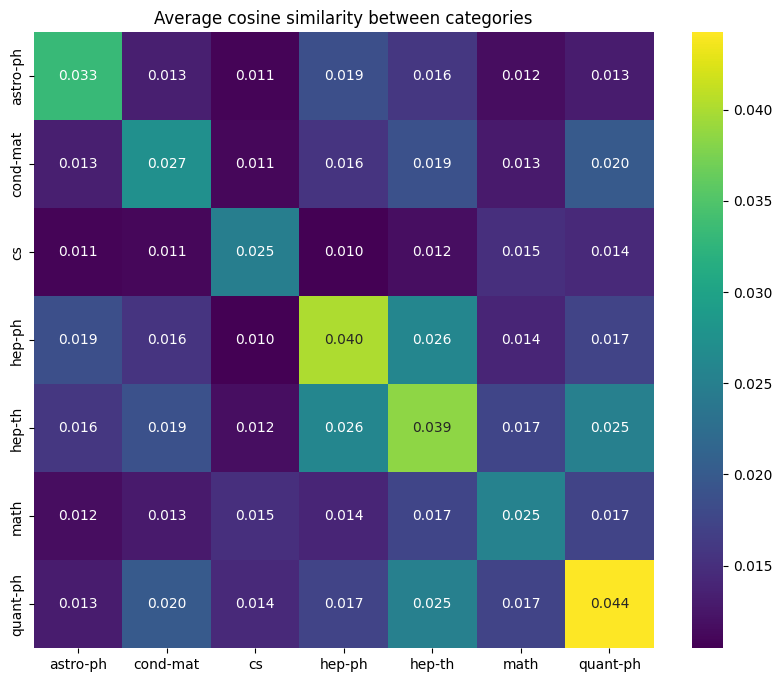

In [10]:
import math
from elasticsearch import Elasticsearch

client = Elasticsearch("http://localhost:9200", request_timeout=1000)
INDEX = "arxiv"

# número total de documentos en el índice (N)
def get_index_N(index=INDEX, client=client):
    return int(client.count(index=index)['count'])

# devuelve dict term->tfidf (normalizada, float)
def get_tfidf(doc_id, index=INDEX, client=client, N=None):
    if N is None:
        N = get_index_N(index, client)
    tv = client.termvectors(index=index, id=doc_id, fields=['text'], term_statistics=True, positions=False)
    if 'term_vectors' not in tv or 'text' not in tv['term_vectors']:
        return {}  # documento vacío o no tiene vector
    terms = tv['term_vectors']['text']['terms']
    vec = {}
    for term, info in terms.items():
        tf = info.get('term_freq', 0)
        df = info.get('doc_freq', 1)
        if df <= 0:
            continue
        idf = math.log(N / df)  # natural log; puedes usar log10 si prefieres
        vec[term] = tf * idf
    # normalizar L2
    norm = math.sqrt(sum(v*v for v in vec.values()))
    if norm == 0:
        return {}
    for t in list(vec.keys()):
        vec[t] = vec[t] / norm
    return vec

def cosine_from_dicts(d1, d2):
    if not d1 or not d2:
        return 0.0
    # iterar sobre el dict más pequeño
    if len(d1) > len(d2):
        d1, d2 = d2, d1
    s = 0.0
    for term, w in d1.items():
        if term in d2:
            s += w * d2[term]
    return s  # vectores ya normalizados => producto punto = coseno

from functools import lru_cache

@lru_cache(maxsize=10000)
def tfidf_cached(doc_id):
    return get_tfidf(doc_id)

def cosine_docs(doc1_id, doc2_id):
    v1 = tfidf_cached(doc1_id)
    v2 = tfidf_cached(doc2_id)
    return cosine_from_dicts(v1, v2)

CATEGORIES = ['astro-ph','cs','hep-th','physics','cond-mat','hep-ph','math','quant-ph']

def extract_category_from_path(path):
    # path ejemplo: /tmp/arxiv/hep-ph.updates.on.arXiv.org/000787
    for cat in CATEGORIES:
        if cat in path:
            return cat
    # fallback: extraer segmento que contenga '-'
    parts = path.split('/')
    for p in parts[::-1]:
        if '-' in p:
            return p.split('.')[0]
    return 'unknown'

from elasticsearch.helpers import scan
from collections import defaultdict

def collect_doc_ids_by_category(index=INDEX, client=client, max_per_cat=None):
    buckets = defaultdict(list)
    for hit in scan(client, index=index, query={"query":{"match_all":{}}}):
        doc_id = hit['_id']
        path = hit['_source'].get('path','')
        cat = extract_category_from_path(path)
        buckets[cat].append(doc_id)
    # opcional: limitar muestras por categoría
    if max_per_cat:
        for cat in list(buckets.keys()):
            buckets[cat] = buckets[cat][:max_per_cat]
    return buckets

# ejemplo: muestreo 200 docs por categoria para que sea manejable
buckets = collect_doc_ids_by_category(max_per_cat=200)

import numpy as np
import pandas as pd
from tqdm import tqdm

def avg_similarity_between_lists(listA, listB):
    # asume listas de doc ids
    total = 0.0
    count = 0
    for a in listA:
        v1 = tfidf_cached(a)
        if not v1:
            continue
        for b in listB:
            v2 = tfidf_cached(b)
            if not v2:
                continue
            total += cosine_from_dicts(v1, v2)
            count += 1
    return (total / count) if count>0 else 0.0

# construir DataFrame de categorías
cats = sorted(buckets.keys())
mat = np.zeros((len(cats), len(cats)))
for i, ci in enumerate(cats):
    for j, cj in enumerate(cats):
        # si i==j, opcional: pares distintos dentro de misma categoría
        if i <= j:
            s = avg_similarity_between_lists(buckets[ci], buckets[cj])
            mat[i,j] = s
            mat[j,i] = s

sim_df = pd.DataFrame(mat, index=cats, columns=cats)
print(sim_df)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(sim_df, annot=True, fmt=".3f", cmap="viridis")
plt.title("Average cosine similarity between categories")
plt.show()

Finally, the following piece of code may be useful to see the content of a few random documents within an index

In [6]:
def print_docs_from_index(index_name, client, max_docs):

    print(f"===================")
    info = client.cat.count(index=index_name, format = "json")[0]
    print(f"Index: {index_name} with {info['count']} documents.")
    print()

    res = client.search(index=index_name, size = max_docs, query= {'match_all' : {}})

    for doc in res['hits']['hits']:
        print (doc['_id'], doc['_source'])

print_docs_from_index('arxiv', Elasticsearch("http://localhost:9200", request_timeout=1000), max_docs=10)

NotFoundError: NotFoundError(404, 'index_not_found_exception', 'no such index [arxiv]', arxiv, index_or_alias)

---

**Exercise 5: (may take time..)**

Can you find duplicate documents in the corpus provided?

---

In [ ]:
# Inspect TF-IDF vector for a document (choose doc_id or let it sample one)
# Set `doc_to_show` to a specific document id (string) if you want, or leave as None to pick a sample.
doc_to_show = None  # e.g. 'doc123' or None

# If None, sample a document from the index
if doc_to_show is None:
    # get one arbitrary doc id (fast) - we use size=1 match_all
    try:
        resp = client.search(index=INDEX, size=1, query={"match_all": {}}, _source=['path'])
        if resp['hits']['hits']:
            doc_to_show = resp['hits']['hits'][0]['_id']
        else:
            raise RuntimeError('No documents found in index')
    except Exception as e:
        raise RuntimeError(f'Error sampling a document: {e}')

print(f"Showing TF-IDF vector for document id: {doc_to_show}")
# attempt to fetch and print the document path if available
try:
    doc_src = client.get(index=INDEX, id=doc_to_show)['_source']
    print('document path:', doc_src.get('path'))
except Exception:
    print('Could not fetch document source or path')

# compute tf-idf vector (uses get_tfidf defined earlier)
vec = get_tfidf(doc_to_show)

if not vec:
    print('Document has empty or no TF-IDF vector (maybe no text or analyzer mismatch)')
else:
    import pandas as pd
    df = pd.DataFrame(list(vec.items()), columns=['term','tfidf']).sort_values('tfidf', ascending=False)
    # show top 50 terms by TF-IDF (adjust as needed)
    from IPython.display import display
    display(df.head(50))
    print(f'Total unique terms in vector: {len(df)}')